## Introduction

An Artificial Neural Network (ANN) is a computational model inspired by the structure and functioning of the human brain. It is designed to learn patterns from data and make decisions or predictions.

ANN is widely used in:

Classification (spam detection, churn prediction)
Regression (price prediction)
Image recognition

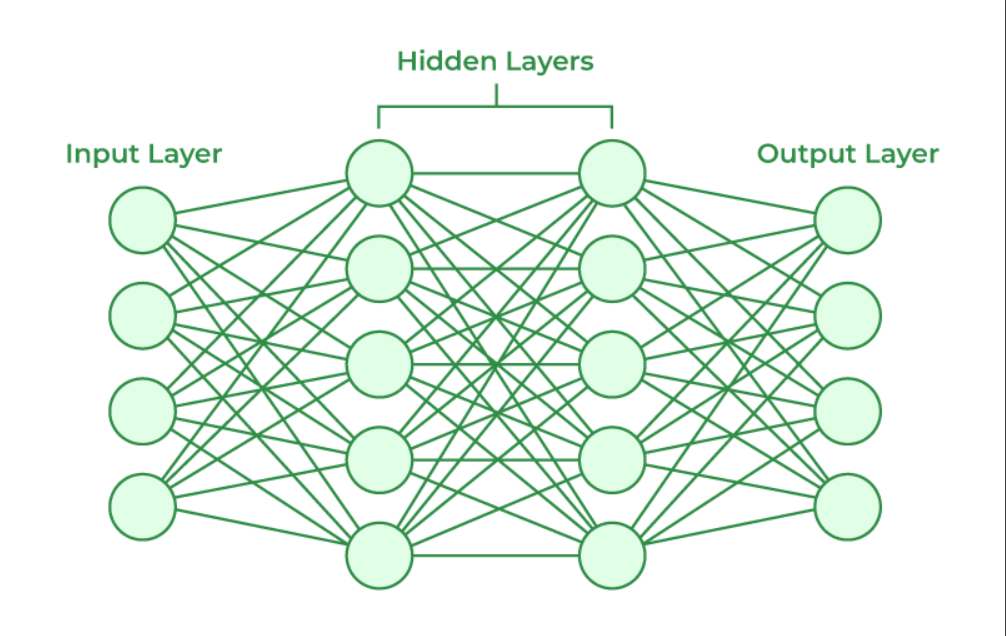

## Input Layer
Takes raw data into the neural network. Each node represents one feature, and no processing is done here.

## Hidden Layers:
They process the data and learn patterns. These layers extract important features and make the network intelligent.
## Output Layer:
Gives the final result of the neural network. It converts learned patterns into a prediction or decision.

## Input Layer → Hidden Layer 1 → Hidden Layer 2 → Output Layer

## Artificial Neuron (Core Unit)

Each neuron performs a mathematical operation:

## Step 1: Weighted Sum
##   n 
## z=∑ wixi+b
##   i=1

## Step 2: Activation Function

## a=f(z)

## Components:
## Component	Meaning
## Input (x)	Data features
## Weight (w)	Importance of feature
## Bias (b)	Threshold
## Activation (f)	Non-linearity

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [8]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [9]:
df = df.drop('customerID', axis=1, errors='ignore')
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [10]:
df = pd.get_dummies(df, drop_first=True)
df

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,Churn_Yes
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,True,True,True,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
7039,0,72,103.20,False,True,True,True,False,True,True,...,False,False,False,False,False,False,False,False,False,False
7040,0,11,29.60,False,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,1,4,74.40,True,True,False,True,False,True,True,...,False,False,False,False,False,False,False,False,False,True


In [11]:
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
model = Sequential()

In [15]:
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

C:\Users\24SW084\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.add(Dropout(0.3))

In [17]:
model.add(Dense(8, activation='relu'))

In [18]:
model.add(Dense(1, activation='sigmoid'))

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32
)

Epoch 1/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5983 - loss: 0.7180 - val_accuracy: 0.7381 - val_loss: 0.9023
Epoch 2/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7428 - loss: 0.5322 - val_accuracy: 0.7417 - val_loss: 0.5373
Epoch 3/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7900 - loss: 0.4123 - val_accuracy: 0.7502 - val_loss: 0.5137
Epoch 4/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8482 - loss: 0.3232 - val_accuracy: 0.7523 - val_loss: 0.5081
Epoch 5/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8901 - loss: 0.2422 - val_accuracy: 0.7828 - val_loss: 0.4963
Epoch 6/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9134 - loss: 0.1910 - val_accuracy: 0.7878 - val_loss: 0.4681
Epoch 7/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9294 - loss: 0.1555 - val_accuracy: 0.7977 - val_loss: 0.4724
Epoch 8/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9443 - loss: 0.1281 - val_accuracy: 0

In [21]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7849538679914834


In [23]:
print(confusion_matrix(y_test, y_pred))

[[978  58]
 [245 128]]


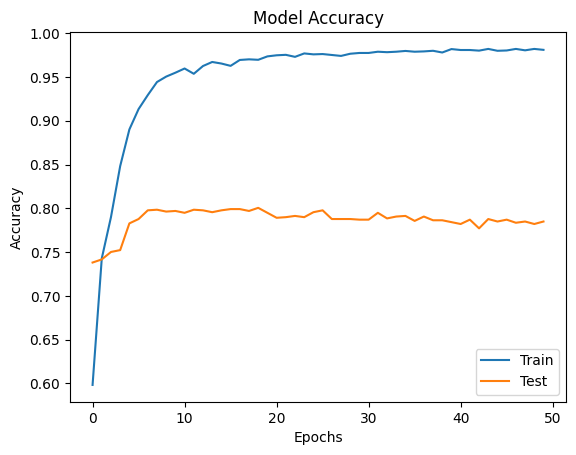

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'])
plt.show()

In [25]:
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

if prediction > 0.5:
    print("Customer will CHURN")
else:
    print("Customer will STAY")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Customer will CHURN
